# Assignment 1: Transformers & Generative Pretrained Transformer (GPT)

The goal of this assignment is to master the **Transformer architecture**, which is the engine behind modern Large Language Models (LLMs) such as ChatGPT, Gemini, and DeepSeek. We will implement a compact, decoder-only transformer from scratch, closely following the [NanoGPT](https://github.com/karpathy/nanoGPT) project by Andrej Karpathy.

We will train this model on textual figure captions from the [Open-MELON dataset](https://huggingface.co/datasets/MartiHan/Open-MELON-VL-2.5K), which contains descriptions of histopathology images (specifically melanocytic lesions). After training, your model will be able to generate **synthetic captions** when prompted with a short starting sequence. Note that at this point we do not associate these captions with image data. We will go into vision-language models that can jointly model both image and text data in the next assignment. For now, we focus on text, but, as you will see in Assignment 2, extending the Transformer architecture to model image data is a straightforward extension.

This dataset was specifically prepared for this course (work done by Martina Hanusova). While this dataset is certainly not as large as the massive corpora used to train ChatGPT and consists of open-access figures and captions rather than medical images and clinical reports, it offers two  advantages. First, the content is highly dense with relevant medical terminology, which makes the training process efficient. Second, because we are using public data from medical publications, we avoid the complex legal and ethical hurdles associated with handling private patient data.

## Preparation

We start with the assumption that you have a solid understanding of fundamental machine learning and neural network concepts, such as linear regression, gradient descent, backpropagation, and loss functions; if you need a refresher, please review materials from the previous courses (e.g. 8BB020 Introduction to Machine Learning). You must prepare for this assignment by mastering the Transformer architecture, specifically understanding self-attention mechanisms in neural networks and the distinction between encoder models and the decoder-only architectures (like GPT) used for generative tasks.

Beyond the architecture, you must also familiarize yourself with the basics of Computational Pathology to understand the medical context of our dataset (we will be generating captions for H&E stained histopathology images).

This is a list of materials that you can use to learn the topic of Transformers and prepare for the flipped classrooms:

| Type | Length | Link | Why is it relevant? |
| :--- | :--- | :--- | :--- |
| Video | 8 min. | [Large Language Models explained briefly (3Blue1Brown)](https://www.youtube.com/watch?v=LPZh9BOjkQs&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=5) | This video from the [3Blue1Brown](https://www.3blue1brown.com/) YouTube channel was originally made as an exhibit for Computer History Museum. It gives a very "gentle" and high-level introduction of the mechanics of how (large) language models work and are trained. This includes the concept of autoregressive modelling (predicting the next word in a sequence), (pre)-training of large language models from text datasets (the "P" in GPT stands for "pretrained") as well as reinforcement learning with human feedback. While in this course we will keep to training of (relatively small) language models, it is good to have the complete picture.  The entire 3Blue1Brown channel is a very high-quality source of educational content on a wide range of topics. In fact, the entire [Neural networks]() playlist is highly recommended, also as a refresher to more fundamental concepts such as backpropagation. |
| Paper | 10 pg. | [Attention Is All You Need (Vaswani et al.)](https://arxiv.org/abs/1706.03762) | This is the paper that introduced the Transformer architecture to the world. It is a must-read for anyone interested in the subject. The paper is relatively short (10 pages without references), however it can be a bit "dense" for beginners. That is ok, as the most important thing to understand is the tokenization of text and the self-attention mechanism. Both of these concepts are also covered in the next two recommended videos so it is best that you iterate between watching the videos and reading the paper. Note that one thing that might be particularly confusing is that the neural network architecture in this paper has both an encoder and decoder part. This is because the application that is addressed here is natural language translation (machine translation). In this setup, the encoder part is used to encode the text in the original language and the decoder is used to translate this encoded text into the target language. In this course we will focus on decoder-only architectures, which are used for generative tasks such as text generation. |
| Video | 27 min. | [Transformers, the tech behind LLMs (3Blue1Brown)](https://www.youtube.com/watch?v=wjZofJX0v4M&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) | This video provides a visual overview of the data flow within a Transformer, specifically focusing on GPT-style (decoder-only) models. It explains tokenization, embeddings (how vectors encode semantic meaning), and the final softmax layer used to predict the next token. It serves as a high-level roadmap of the architecture before diving into specific components in the next video. |
| Video | 26 min. | [Attention in transformers (3Blue1Brown)](https://www.youtube.com/watch?v=eMlx5fFNoYc&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) |This chapter breaks down the Attention mechanism (Self-Attention), which is the core innovation of the Transformer. It details the Query, Key, and Value (Q, K, V) matrices and visualizes how the attention pattern is calculated via dot products. It explains how the model uses these to "attend" to relevant context (updating word meanings based on surrounding words) and introduces concepts like multi-head attention and masking. |
| Interactive tool | ~25 min. | [Transformer explainer (poloclub)](https://poloclub.github.io/transformer-explainer/)| This is a great interactive tool that explains in steps how transformer models for language work and make predictions. It should take around 25 minutes to go over all the steps in the tool for one example, but it might be useful to spend some more time and look at different examples. |
| Video | 120 min. | [Let's build GPT: from scratch, in code, spelled out (Andrej Karpathy)](https://www.youtube.com/watch?v=kCc8FmEb1nY) | This video series provides a step-by-step guide to building a GPT-style transformer from scratch. It covers the entire process, from data preparation to model training and evaluation. It is a great resource for understanding the mechanics of how GPT-style models work and how to implement them in code. It is **optional** in a sense that it is not required for the exercises, but might be very useful for understanding the dataset and **formulating an research question for the open assignment.** |
| Paper | 11 pg. | [From melanocytes to melanomas (Shain et al.)](https://www.nature.com/articles/nrc.2016.37) | This review paper provides a good overview of the biology of melanocytic lesions and the histopathology of melanocytic lesions. It is a good resource to understand the medical context of our dataset.|
| Paper | 35 pg. | [Large Language Models: A Survey (Minaee et al.)](https://arxiv.org/abs/2402.06196) | This survey paper is a good resource to get the "big picture" of various large language models and how they differ in their methodology and implementation. Treat this resource as **optional**. It is not required to complete the exercises in this assignments, but it is very useful to get a broader understanding of the state-of-the-art, which you might find useful for **generating ideas for the open assignment** or future projects (e.g. for your BEP or MSc projects). |

## Exercises: Theory

⚠️ *The answers to the theory exercises are NOT to be submitted as part of the assignment deliverables. They can, however, be used to check your understanding of the materials and to prepare for the flipped classroom. You CAN include your discussion about the exercises in the flipped classroom log.*

#### Exercise T.1

A GPT model is autoregressive, meaning it generates text strictly one token at a time. It predicts the first next token, appends it to the sequence, and uses that updated sequence to predict the second token. This is a serial process.

In contrast, many other neural networks process their entire input in parallel (all at once) to maximize speed.

If we modified the architecture to predict every token in a paragraph simultaneously (in parallel) rather than one by one, is the resulting text likely to be grammatically coherent? Explain your reasoning.

#### Exercise T.2

In this assignment (as you will see later), we define tokens to be individual characters (e.g., 'a', 'b', 'c'). This keeps our vocabulary small and the implementation simple. In contrast, the standard practice for modern Large Language Models is to use sub-word tokenization, which groups frequent character patterns into single tokens to process text more efficiently.

Assume that we take this concept one step further and define tokens to be entire sentences. What would be the consequence of this when generating text?

#### Exercise T.3

The core concept of a Transformer is self-attention, which allows a token to look at other tokens to gather context. In a Decoder-only model (like GPT), we apply a specific constraint called Causal Self-Attention (or "Masked" Self-Attention) during training. This forces every token to look only at itself and the tokens that came before it.

This is different from Encoder models, which use Bidirectional Attention, allowing tokens to see the entire sentence (past and future) at once.

Assume that during training, we feed the entire completed sentence into the model at once. Will this model still be useful for generating text? Explain your reasoning.

#### Exercise T.4

Decoder-only models (like GPT) are mathematically optimized to maximize the probability of the text sequence. This means that if they were trained with medical report data, they strive to generate text that "looks" and "sounds" like a real medical report. They are not optimized to check for factual truth.

Assume that your trained model generates a synthetic pathology caption that includes specific quantitative details: "The sample shows a high mitotic rate of 8 figures per 10 HPF."

Why is this specific type of error (a plausible-sounding number) significantly more dangerous to a clinician than if the model had just generated obvious gibberish (e.g., "rate figures high 8 10" )?

#### Exercise T.5

If we want to train a model that generates a pathology report based on medical imaging data, we would need a joint vision-language model. We will touch on this in the next assignment. For now, assume that we want to generate a report based on some medical test or observations that we can represent as text data and make them part of the starting sequence that we use to prompt further generation.

Consider the following example of how such a model would operate:

Input Sequence (Provided by User): "Clinical Indication: Patient has a rapidly growing, asymmetrical black lesion on the left shoulder. Rule out Melanoma. Gross Description: ..."

Generated Continuation (Predicted by Model): "...Specimen consists of a skin ellipse measuring 2.0 x 1.5 cm. Microscopic examination reveals a proliferation of atypical melanocytes arranged in nests at the dermo-epidermal junction. There is upward migration of cells (pagetoid spread). DIAGNOSIS: MALIGNANT MELANOMA."

Would such a model be useful in clinical practice? Motivate your answer.


## Before you Begin...

### Dataset

[Open-MELON-VL-2.5K](https://huggingface.co/datasets/MartiHan/Open-MELON-VL-2.5K) is a vision–language dataset of 2,500 Hematoxylin & Eosin-stained histopathology images of melanocytic lesions with captions, curated from PubMed open-access publications. It is hosted on Hugging Face, which is a platform for sharing and accessing datasets.

### GPU Usage

For the assignments, we recommend to use GPU for faster model training or evaluation.
[Google Colab](https://colab.research.google.com) provides a free service for hosting Jupyter notebooks allowing to access a remote Tesla T4 GPU.
Please keep in mind the Colab free tier GPU usage limits (approximately 1.5 hours per day, but may be higher or lower depending on your usage history).

To enable a GPU in Colab, navigate to the menu panel -> `Runtime` -> `Change runtime type` -> `T4 GPU` -> `Save`.
When you are done with your work, detach the current runtime session and download the Jupyter notebook file locally.

⚠️ *Note that all assignments are designed to also be doable on the CPUs of your laptops, so you do not have to use Colab or a GPU.*

## Training a Generative Language Model

### Install Required Packages

This notebook uses:
- `numpy` for basic math operations
- `datasets` to load captions from Hugging Face
- PyTorch to implement NanoGPT-like model + training loop
- `tqdm` for displaying progress bars

All other used packages should already be available on your system. If you need help with setting up your Python environment, please ask help from your assigned TA.

Let's install the required packages:

In [ ]:
!pip install numpy datasets torch tqdm

### Import the Libraries

The following Python modules will be used for our NanoGPT implementation.

In [3]:
import os
import math
import random
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np

from datasets import load_dataset, concatenate_datasets

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.auto import tqdm

### Load the Dataset

In the code block below, [Open-MELON dataset](https://huggingface.co/datasets/MartiHan/Open-MELON-VL-2.5K) is loaded using HuggingFace loaders and the figure captions are concatenated into one big training corpus.


In [4]:
# ds_dict is a list of ['train', 'validation', 'test'] splits
ds_dict = load_dataset("MartiHan/Open-MELON-VL-2.5K")

# in this example, all 3 splits are concatenated
# validation set is later drawn from the text chunks of 'block_size'
ds_all = concatenate_datasets(list(ds_dict.values()))

captions = [str(x) for x in ds_all["caption"]]
print("Captions:", len(captions))
print("Example caption:", captions[0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/415M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/362M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/143M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1726 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/375 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/398 [00:00<?, ? examples/s]

Captions: 2499
Example caption: Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.


#### Preprocess the Training Text

We join separate captions with `<ENDC>` separator. This helps the model learn boundaries.


In [5]:
SEP = "\n<ENDC>\n"
text = SEP.join(captions)

# Print the total number of characters in the dataset
print("Training text length (chars):", len(text))

# Print the first 1000 characters of the constructed text corpus
print(text[:1000])

Training text length (chars): 971654
Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.
<ENDC>
Histopathology of small bowel polyps showing malignant cells arranged in diffuse sheets with the presence of intracytoplasmic and extracellular pigments. The image is stained with hematoxylin and eosin (H&E) at × 20 magnification.
<ENDC>
Small bowel polyps showing malignant cells located at the lamina propria and submucosa. The image is stained with hematoxylin and eosin (H&E) at × 4 magnification.
<ENDC>
Histopathology showing spindle cell uveal melanoma from a left eye choroidal pigmented malignant melanoma, classified as invasive in the ciliary body and cornea (stage IIIB, pT4bN0M0). The microscopic examination reveals a dense cell proliferation composed of small and medium fusiform (spindle) cells, along with evident pigment production. The tissue fragments were embedded in par

### Character-level Tokenizer

We build a vocabulary of unique characters from the training text.


In [15]:
#text = text.lower() #converting all characters to lower-case letters
chars = sorted(list(set(text)))
vocab_size = len(chars)

# mapping of characters to numerical tokens (by their order in vocabulary alphabet)
stoi = {ch:i for i,ch in enumerate(chars)}

# mapping of numerical tokens back to characters
itos = {i:ch for i,ch in enumerate(chars)}

def encode(s: str):
    """
    Converts character to a token.
    Input: character (e.g. 'A')
    Output: numerical token (e.g. 65)
    """
    return [stoi[c] for c in s]

def decode(ids):
    """
    Converts token to a character.
    Input: numerical token (e.g. 65)
    Output: character (e.g. 'A')
    """
    return "".join(itos[i] for i in ids)

Let's print some information about the vocabulary that we have created as well as some examples of encoding words.

In [16]:
print("Size of the vocabulary:", vocab_size)
print("Preview of the vocabulary:", chars)

examples = ["male", "malignant", "melanoma", "malignant melanoma"]

print("\n--- Encoding Examples ---")

for word in examples:
    tokens = encode(word)

    # Create a visual mapping of Char -> Token
    mapping_str = ", ".join([f"'{c}':{t}" for c, t in zip(word, tokens)])

    print(f"String:  {word}")
    print(f"Tokens:  {tokens}")
    print(f"Mapping: {mapping_str}")
    print("-" * 40)


Size of the vocabulary: 83
Preview of the vocabulary: ['\n', ' ', '"', '#', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '[', ']', '^', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '\xa0', '§', '°', '±', '²', '´', 'µ', '×', 'í', 'α', 'μ', '\u2005', '\u2009', '‐', '–', '‘', '’', '“', '”', '→', '⇒', '≤', '≥', '⊷']

--- Encoding Examples ---
String:  male
Tokens:  [45, 33, 44, 37]
Mapping: 'm':45, 'a':33, 'l':44, 'e':37
----------------------------------------
String:  malignant
Tokens:  [45, 33, 44, 41, 39, 46, 33, 46, 52]
Mapping: 'm':45, 'a':33, 'l':44, 'i':41, 'g':39, 'n':46, 'a':33, 'n':46, 't':52
----------------------------------------
String:  melanoma
Tokens:  [45, 37, 44, 33, 46, 47, 45, 33]
Mapping: 'm':45, 'e':37, 'l':44, 'a':33, 'n':46, 'o':47, 'm':45, 'a':33
----------------------------------------
String:  

Now we encode the text corpus and store it as PyTorch array. The first 90% of this array will be used for training, while the remaining 10% will be used for validation.

In [17]:

data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split: str):
    src = train_data if split == "train" else val_data
    ix = torch.randint(len(src) - cfg.block_size - 1, (cfg.batch_size,))
    x = torch.stack([src[i:i+cfg.block_size] for i in ix])
    y = torch.stack([src[i+1:i+cfg.block_size+1] for i in ix])
    return x.to(cfg.device), y.to(cfg.device)

print("Train tokens:", train_data.numel(), "Val tokens:", val_data.numel())

Train tokens: 874488 Val tokens: 97166


### Model Training Configurations

The following configuration classes define the size of the transformer model and how it is trained. These hyperparameters control model capacity, context length, training stability, and computational cost. You can later use this to perform different experiments, e.g. comparing models of different size (capacity) and context length.

**Model configuration**

- `vocab_size` - number of unique tokens the model can process. In this assignment, tokens are individual characters, so the vocabulary size equals the number of distinct characters in the training corpus.

- `block_size` - the context window length, i.e. the maximum number of tokens the model can see at once. During training and generation, the model predicts the next token using only the previous block_size tokens. A larger block size allows the model to capture longer-range dependencies but increases memory and computation requirements.

- `n_layer` - number of stacked transformer decoder blocks. More layers increase model depth and expressiveness but also training time and risk of overfitting.

- `n_head` - number of attention heads in each self-attention layer. Multiple heads allow the model to attend to different aspects of the context simultaneously (e.g. syntax, formatting, or local patterns).

- `n_embd` - dimensionality of token embeddings and hidden representations. Larger embeddings allow richer representations but increase memory usage and compute cost.

- `dropout` - dropout probability used during training as a regularization technique. It helps prevent overfitting by randomly deactivating neurons. Dropout is disabled for CPU training to keep behavior deterministic and training stable.

**Training configuration**
- `batch_size` - Number of training sequences processed in parallel during one optimization step. Larger batches improve gradient stability but require more memory.

- `max_iters` - total number of training iterations (parameter update steps).

- `eval_interval` - number of training iterations between evaluations on the validation set.

- `eval_iters` - number of mini-batches used to estimate training and validation loss during evaluation.

- `lr (learning rate)` - step size used by the optimizer when updating model parameters. This is one of the most sensitive hyperparameters for training stability.

- `weight_decay` - regularization term that penalizes large weights and helps reduce overfitting.

- `device` - specifies whether training runs on CPU or GPU. Smaller model and batch sizes are used automatically when no GPU is available.


In [18]:
##############################################################################################
### Model configuration (number of layers, number of heads, embedding dimensions, dropout) ###
##############################################################################################

# Configuration for GPU
@dataclass
class ModelConfigGPU:
    vocab_size: int
    block_size: int
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 256
    dropout: float = 0.2

# Configuration for CPU
@dataclass
class ModelConfigCPU:
    vocab_size: int
    block_size: int
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 128
    dropout: float = 0

########################################################################################################
### Model configuration (block size, batch size, evaluation iterations, learning rate, weight decay) ###
########################################################################################################

# Configuration for GPU
@dataclass
class TrainConfigGPU:
    block_size: int = 256
    batch_size: int = 64
    max_iters: int = 2000
    eval_interval: int = 250
    eval_iters: int = 200
    lr: float = 1e-3
    weight_decay: float = 0.1
    device: str = "cuda"

# Configuration for CPU
@dataclass
class TrainConfigCPU:
    block_size: int = 64
    batch_size: int = 12
    max_iters: int = 2000
    eval_interval: int = 200
    eval_iters: int = 50
    lr: float = 1e-3
    weight_decay: float = 0.1
    device: str = "cpu"
    compile: bool = False


# Automatically select suitable configuration based on GPU detection
if torch.cuda.is_available():
  ModelConfig = ModelConfigGPU
  TrainConfig = TrainConfigGPU
else:
  ModelConfig = ModelConfigCPU
  TrainConfig = TrainConfigCPU


### Building the NanoGPT Model

The model begins with token embeddings, which map character indices to dense vectors, and positional embeddings, which encode the order of tokens within a fixed context window (`block_size`). These embeddings are added together and passed through a stack of transformer decoder blocks.

Each decoder block consists of two main submodules: causal self-attention and a feed-forward network (MLP). Causal self-attention allows each token to attend only to previous tokens by applying a causal mask, ensuring that the model cannot access future information during training or generation. Multiple attention heads are used so that the model can focus on different aspects of the context in parallel. The MLP applies a non-linear transformation independently at each position, complementing the attention mechanism. Layer normalization and residual connections are used throughout to stabilize training and preserve information flow.


In [19]:
class CausalSelfAttention(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        assert c.n_embd % c.n_head == 0
        self.n_head = c.n_head
        self.head_dim = c.n_embd // c.n_head

        self.qkv = nn.Linear(c.n_embd, 3 * c.n_embd, bias=False)
        self.proj = nn.Linear(c.n_embd, c.n_embd, bias=False)
        self.dropout = nn.Dropout(c.dropout)

        mask = torch.tril(torch.ones(c.block_size, c.block_size)).view(1, 1, c.block_size, c.block_size)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=2)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.proj(y)
        y = self.dropout(y)
        return y

class MLP(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        self.fc = nn.Linear(c.n_embd, 4 * c.n_embd)
        self.proj = nn.Linear(4 * c.n_embd, c.n_embd)
        self.dropout = nn.Dropout(c.dropout)

    def forward(self, x):
        x = self.fc(x)
        x = F.gelu(x)
        x = self.proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(c.n_embd)
        self.attn = CausalSelfAttention(c)
        self.ln2 = nn.LayerNorm(c.n_embd)
        self.mlp = MLP(c)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

After passing through all decoder blocks, the model applies a final layer normalization and a linear output head that produces a probability distribution over the vocabulary for the next-token prediction. The training objective is standard cross-entropy loss between the predicted next token and the true next token.

This NanoGPT model contains approximately between 0.8 and 3 million parameters, depending on the configuration. By comparison, GPT-2 contains hundreds of millions of parameters and modern commercial language models contain many billion parameters. Despite this difference in scale, the same architectural principles apply. The total number of parameters is mainly determined by the embedding dimension (`n_embd`), the number of layers (`n_layer`), and the vocabulary size, while the number of attention heads controls how the embedding space is partitioned rather than its overall size.

The model is intentionally kept small so that it can be trained quickly on limited hardware and easily inspected. The goal of this assignment is to understand how transformer components interact, not to achieve state-of-the-art language modeling performance.

In [20]:
class NanoGPT(nn.Module):
    def __init__(self, c: ModelConfig):
        super().__init__()
        self.c = c
        self.tok_emb = nn.Embedding(c.vocab_size, c.n_embd)
        self.pos_emb = nn.Embedding(c.block_size, c.n_embd)
        self.drop = nn.Dropout(c.dropout)
        self.blocks = nn.ModuleList([Block(c) for _ in range(c.n_layer)])
        self.ln_f = nn.LayerNorm(c.n_embd)
        self.head = nn.Linear(c.n_embd, c.vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.c.block_size
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)

        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

cfg = TrainConfig()
mcfg = ModelConfig(vocab_size=vocab_size, block_size=cfg.block_size)

model = NanoGPT(mcfg).to(cfg.device)
print("Parameters:", sum(p.numel() for p in model.parameters())/1e6, "M")


Parameters: 3.263488 M


### The Training Loop

We use the AdamW optimizer and periodically evaluate on the validation set. The training in Google Colab should take for both the CPU and GPU configurations approximately 4-5 minutes using the baseline configuration.

In [10]:
# used for question 2 instead of the below mentioned training loop code
train_losses = []
val_losses = []
iterations = []

@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(cfg.eval_iters)
        for k in range(cfg.eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

model.train()
pbar = tqdm(range(cfg.max_iters), desc="training")
for it in pbar:
    if it % cfg.eval_interval == 0:
        losses = estimate_loss()

        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        iterations.append(it)

        pbar.set_postfix(
            train=losses["train"],
            val=losses["val"]
        )

    xb, yb = get_batch("train")
    _, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

training:   0%|          | 0/2000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [21]:
@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(cfg.eval_iters)
        for k in range(cfg.eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

model.train()
pbar = tqdm(range(cfg.max_iters), desc="training")
for it in pbar:
    if it % cfg.eval_interval == 0:
        losses = estimate_loss()
        pbar.set_postfix(train=losses["train"], val=losses["val"])

    xb, yb = get_batch("train")
    _, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()


training:   0%|          | 0/2000 [00:00<?, ?it/s]

### Text Generation (Sampling)

Now that the model is trained we can put it to use. We generate the synthetic captions starting from `"H&E stained section showing"` string by autoregressively sampling next characters

Hyperparameters:
- `temperature`: higher = more random, lower = less variety
- `top_k`: restrict sampling to top-k most likely chars (lower number eliminates less likely candidates)

In [22]:
@torch.no_grad()
def generate(start: str, max_new_tokens=400, temperature=1.0, top_k=30):
    model.eval()
    idx = torch.tensor([encode(start)], dtype=torch.long, device=cfg.device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -cfg.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / max(temperature, 1e-6)

        if top_k is not None:
            v, _ = torch.topk(logits, k=min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = -float("Inf")

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    return decode(idx[0].tolist())

prompt = "H&E stained section showing"
#prompt = prompt.lower()

print(generate(prompt, max_new_tokens=500, temperature=0.7, top_k=10))


h&e stained section showing malignant neoplastic cells with abundant cells with the left collagen bundles. these cells are arranged in spitz nevus with squamous epithelium. stained with hematoxylin and eosin (h&e) at ×200 magnification.
<endc>
histopathology showing features of an epidermis, stained with hematoxylin and eosin (h&e) at ×40 magnification. the image displays a condense of the left he epidermis with prominent nucleoli. the image is stained with hematoxylin and eosin (h&e) and viewed at ×200 magnification.
<en


### Plotting

The following code was used for the plotting for question 2

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(iterations, train_losses, label="Training Loss")
plt.plot(iterations, val_losses, label="Validation Loss")

plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Iterations")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

⚠️ *Everything below this line must be submitted as a deliverable for this assignment.*

ℹ️ *Answering the exercises below will require you to implement new code and/or modify the code in cells above. You can add the code directly in the notebook or in separate Python files, depending on your preference. If you write code in separate files, please do not forget to also submit them. The exercises will also require re-running the training, sometimes multiple times. You can split the workload among the group members so things are done more efficiently.*

## Exercises: Practice

#### Exercise 1

When we created the text corpus, we used the <ENDC> separator to mark the end of a caption. Why is the <ENDC> separator needed? What would happen if you use a model trained without such separator in practice? In order to investigate this, train a model without the <ENDC> separator and compare the results with the model trained with the <ENDC> separator when generating captions.

#### Exercise 2

Train the model and plot training loss and validation loss as a function of training iterations. Modify the following hyperparameters and observe the effect:
- Learning rate
- Batch size
- Evaluation interval

Explain why the observed changes occur. What patterns indicate underfitting? What patterns suggest overfitting or unstable training?

#### Exercise 3

We can reduce the number of tokens by converting all letters to either uppercase or lowercase. Implement this in the preprocessing function and retrain a model. Report your observations on the training and performance of the model.


#### Exercise 4

The dataset contains 2500 figure captions. After encoding and splitting out 10% of the tokens for validation, we are left with 874488 training tokens. Is this also the number of training samples used to train our NanoGPT model? If yes, explain why, if not try to estimate the actual number of training samples.

#### Exercise 5

Text generation depends strongly on the sampling hyperparameters.

Generate captions using at least three different temperature values and two different top_k values. Include at least 10 generated examples per hyperparameter configuration in your report.

For each configuration, comment on the following characteristics of the generated samples:
  - Fluency and structure
  - Repetition or degeneration
  - Factual plausibility (even if the content is synthetic)

Identify optimal configuration of parameters that balances coherence and diversity of the produced synthetic captions, and justify your choice.

## Flipped Classroom Log

ℹ️ *You have to fill this log for both flipped classroom sessions for this assignment. You only fill the log for your group, not together with the group that you interacted with.*

### Instructions

#### Preparation
* **Clients:** List specific theoretical or implementation (code) questions prepared before class.
* **Consultants:** List papers, videos, or code documentation reviewed to prepare. Note, this is not limited to the material listed above, you can add any new material that you used or found useful.

#### Peer Interaction
* **Clients:** Summarize the solutions or explanations received.
* **Consultants:** Summarize advice given and specific resources shared.



# **Answers to exercises**
**Answer Exercise 1**

Changes to the code:

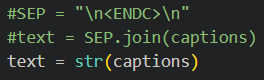

The difference between the models is that whilst the original model outputs sentences that are similar length and structure to the given input sentences with no repeating information. The one without separators has problems with sentence length, structure and the resetting of the context between sentences. This results in sentences that are too long with repeating information.

**Answer Exercise 2**

Plots regarding this excercise are given below with their designated changes and the edited code can be seen at the plotting section at the bottom of the programming segment and at the training loop section.

Learn rate

The learning rate (lr) is how big a step the model takes when it updates its weights.

-	Higher
  - The higher learning rate has resulted in the curves to be less smooth and have more jumps which are signs of instability they also seem to be closer together which can be a sign of underfitting.
-	Lower
  - The higher learning rate has resulted in the curves to be initially less smooth and have more jumps which are signs of instability they also seem to be closer together which can be a sign of underfitting.

Batch size

Batch size is the number of training samples the model processes at once before updating its weights.

-	Higher
 - There was minimal change, however the 2 curves are separating more which is a sign of overfitting.
-	Lower
 - Loss has increased as a sign instability, the curves are also closer together as a sign of underfitting

Evaluation interval

The evaluation interval is how often validation metrics are computed during training. Which is seen by looking at which interval the curve changes direction.

-	Higher
 -	Less smooth and a loss of information. There is no change in overfitting, underfitting and stability.
-	Lower
 - Extremely smooth and a lot of information was added. There is no change in overfitting, underfitting and stability.


**Answer Exercise 3**
Changes in the code to convert all letters to lowercase letters:
- in cell 4: add "text = text.lower() #converting all characters to lower-case letters" before the line "chars = sorted(list(set(text)))" to change the generate only lower case letters.
- in cell 13: add "#prompt = prompt.lower()" after "prompt = "H&E stained section showing" to make sure the prompt contains only tokens that are in the vocabulary.

Due to the smaller amount of tokens, the model trains slightly faster. However, this effect is minimal, since the origional vocabulary containing uppercase lettes is already relatively small.
Comparison of the case with and without capital letters included in the vocabulary, shows that the exclusion of capital letters does not significanly affect the models ability to generate gramatically correct text. Overall sentence structure and medical meaning largely remain intact, which indicates that capitalization is not strictly necessary for producing correct text outputs.
However, in a medical context, capitalization provides domain-specific and structural clues. For example, abbreviations like "H&E" should be capitalized when using correct medical terms. Text in which only lowercase tokens are used, therefore are less professional and domain specific. Considering the medical context in which this model in employed, in which capitalizations could signify domain specific emphasis, the use of lowercase tokens exclusively is not preferred.

**Answer Exercise 4**
The number of captions used for training is the number of training samples. So 874488 is the number of tokens used in training, and not the number of training captions. If we assume that all captions are approximately equally long, then 90% of captions is used for training. This are more or less 2250 captions, so the number of training samples should be around 2250.


**Answer Exercise 5:**
The first temperature and top_k combination I tried is the one given. So temperature=0.7 and top_k= 10. These are lower than the default values set  in the function.
 The 10 generated examples for this are:

- H&E stained section showing a basal cell carcinoma.
  <ENDC>
  Histopathology of a nodular melanoma (Case 3) from the patient diagnosed with a 25-year-old man, showing a demarcating proliferation of basaloid cells with prominent
  at the dermo-epidermal junction and desmoplastic melanoma in situ. The image is stained with Hematoxylin and Eosin (H&E) at ×100 magnification, shows a cellular
  dermal neoplasm with abundant eosinophilic cytoplasm, and veiident nuclei with or eosinophilic cytoplasm, and prominent nucleoli. The image i
- H&E stained section showing malignant melanoma in a hematoxylin and eosin (H&E) at ×200 magnification.
  <ENDC>
  High-magnification (hematoxylin and Eosin staining) showing a papillary dermis, indicated by a black structure with pattern due to a malignant melanoma, which is
  a compared tumor cells arranged in a papillary dermis. The image, confirming the diagnosis of an epidermal lymph node and a distinct cell proliferation around
  hyalinization of pleomorphic cells with abundant cytoplasm, and minous and hyperchromatic nuclei
- H&E stained section showing features of atypical cells. These cells are   present in an abundant eosinophilic cytoplasm and eosinophilic cytoplasm arranged in a large
 anastomosingle) in the dermis, often bundles of the cells arranged in nests. The basophilic cells are also present with abundant eosinophilic cytoplasm and hyperchromatic
 nuclei, arranged in a small nucleoli. The cells exhibit prominent nucleoli and and nucleoli arranged in nests, with vacuolated characterized by a solid number of collagen
 bundles cells arrang
 - H&E stained section showing a proliferative tumor cells and present dermal nests of large cells in the dermis, containing epithelium is and by a solid nests of epithelioid tumor cells. The image is stained with Hematoxylin and Eosin (H&E) at 400x magnification.
<ENDC>
Histopathology showing an apoptotic parance of the epidermis and sebocytes with hyperchromatic nuclei, and abundant melanin pigmentation in the nail layer of the epidermis. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
- H&E stained section showing a nodular lesion of the epidermis with a proliferation of mature nucleoli, conspicuous nucleoli. Stained with hematoxylin and eosin (H&E).
<ENDC>
Histopathology showing a predominantly and a solid pathological connected to the lesion the reatment rectaging for diagnosis. The malignant melanoma shows a regularly
area of pseudoincluding a melanoma cell carcinoma in the did area indicated by a blue arrow). The image is stained with Hematoxylin and Eosin (H&E) and captured at
×200 magnification.
<E
-
 H&E stained section showing tumor cells arranged in anastomosing areas of epithelioid tumor cells with lumen between the normal cells and nastomosing cords of basaloid
cells within the large and small clusters of pigmented spindle cells. Magnification: ×200.
<ENDC>
Histopathology showing a desmoplastic cells with a rectanged cellular blue nevus cells with variable nucleus cytoplasm and vesicular nuclei with prominent nucleoli,
and containing eosinophilic cytoplasm, vacuolated cytoplasm, prominent nucleoli, and no cytoplas
- H&E stained section showing nests of epithelioid melanocytes with abundant cytoplasm, vesicular nuclei, and prominent nucleoli. The tissue is stained with Hematoxylin
and Eosin (H&E) and viewed at ×200 magnification.
<ENDC>
Histopathology of a lesion from a 76-year-old male, initially submitted with a submittte proliferation of pagetoid squamous epithelium with distinct and dense cells
 intermedium- containing extensive and epithelioid cells with eosinophilic cytoplasm also prominent nucleoli, prominent nucleoli, and abund
- H&E stained section showing melanocytes in the dermis. The image is stained with hematoxylin and eosin (H&E) and viewed at ×200 magnification.
<ENDC>
Histopathology showing the cyst wall consistent with a proliferation of spindle cell carcinoma. The image is stained with Hematoxylin and Eosin (H&E) at ×400 magnification.
<ENDC>
Histopathology of an asymptomatic proliferation of skin biopsy, stained with Hematoxylin and Eosin (H&E) at ×200 magnification. This image shows a mixed atypical
melanocytic proliferation with larg
- H&E stained section showing atypical melanocytes with abundant pigment granular pleomorphism and vesicular nuclei, prominent nucleoli,
prominent nucleoli, and prominent nucleoli, and abundant myxoid cytoplasm and prominent nucleoli, and prominent nucleoli, which are also observed,
which are present with conspicuous nucleoli, containing eosinophilic cytoplasm. Stained with hematoxylin-eosin; original magnification 100×.
<ENDC>
Histopathology showing number of the dermis and subepithelial nevus cells in the upper dermis wit
- H&E stained section showing proliferation of nodular melanoma cells can be observed in the dermis and subcutaneous mass in the upper dermis,
containing epithelium and decapitative tissue. The image is stained with hematoxylin and eosin (H&E) and viewed at ×600 magnification.
<ENDC>
Histopathology showing a low-group pigmented cells arranged in a sheet-like cell poorly differentiated nests of nevus cells with abundant eosinophilic cytoplasm and
 a high nucleus arranged in small nuclear pleomorphism and a connective tissue a

Analysis:
*Fluency and structure: The fluency is much better than at a temperature of 2.0 for example.
                        There are mostly coherent sentences formed that are grammatically correct. The output is still not perfect though:
                        There are still some spelling mistakes and also some illogical sentences like 'diagnosed with a 25 year old man'. The sentence structure is okay, and in most captions there is a structure in the sense that it ends with the stain and magnification.

*Repetition or degeneration: There is still some repetition present, for example 'eosinophilic cytoplasm and eosinophilic cytoplasm',
                            it is less than with a higher temperature and more the repitition of words than of individual tokens.
*Factual plausibility (even if the content is synthetic): For the captions that are not nonsense and have a structure and actual diagniosis,
                               I would say tha the factual plausibility is okay, however, not all captions form a coherent story and diagnosis.
So even with a temperature of 0.7 there will be some mistakes.  

The next combination I have tried is: temperature = 2.0; top_k = 10, in order to see the effect of temperature clearly. I also increased the max_new_tokens to 500, because the text keeps getting cut off.  
The generated captions for this are:

- H&E stained section showing tumor cytooliform atypia. MCaps whitr mucosis initially rom associated with fibrix,-anaple mant.
<ENDC>
Histologic features showed a noduling tumor.
<ENDC>
Histopathology frimna excision, irrs mild duct ell nevoma a 61-year-old man who femalin. Them presented with lensive, proliferation with a papillaries of papillobular cordeceition and during epidermis, capsulaed, spirdline cordensive/ecentroudulary exophytic mesen, mucin gencative strogin,. Stained with Hematoxylin'.” Histologic favored ecta
- H&E stained section showing nupous hornyodsulyt, ecceistic mixed mass. Thee cytole is thicklendow compresenced in the uper elongapsulli.
<ENDC>
Hibtaion of acanter. Histological ev mut is charged by to by a sightly, diregulosely-cildal-sized biphenocytoplasm.” Mat imateris sebaceous grove. Intracess infiltratory cells, alonrmal), wliles susmingle-to-like” clinic-types, lhin, rregular-brownish to epidermoly irregular differus.
<ENDC>
Histopathology showingous cytoteular pspars lack-relyih and. Adjacent mitotes
ly, sowing e

I am increasing the max_tokens to 600

- H&E stained section showing small cells sapen of storiformatible cysts apoptiasis to the preceific asymmentratifical from a 48-μagnification with a dragmented,” dysplastic neoplasia. Sebocriet lumn tumor shave necrophil(EN)-largeyer-likke eosin stranges, with the llucts to any misidencinges. It subsequequenilg, excpsied as multiple, wavy their serians cattous lichenes for POLS (CMM.”
<ENDC>
Histosatopathology stained with hematoxylin-Eosin-[Magnificatio), choronocytomus, illustrates betweing clofined adiphenoid' celli talm. The surfictle duamargin-cocysly poorled papocrimedoglandoma,” especifically irregularlying, arthy
- H&E stained section showing nutal famyloid-eosin, which some and some of ceded cysts occurring invasia smoottouding tissue. Specively small cuboid-like tumor-inkhalignear morphology and desmoplastic sipindle-shape; moderaneoma. Other ipthelioid spread), ocansiped themor tumor cells, typical focaly, prominenl nucleoli) of nuncapsular meldoma. It ulcearly; hemosiderpigment was pre-tanodule. Multiple cells suted atypical eosinophilic cytoplasis, circeating amorphous seen in malignancy), characterized brtic/pigmented and differential facter. It also nitially stugtezed also identificibited by flomic-epidermal aggrab-lackized
- H&E stained section showing that anaimmartofibrosam. THis details shows ibord-fattures ofseb-cells irregular macropillaria (AM). The inner melan-A low-granulomasing–linesrvative, confirming by such circibes fa pT9a dysliing, papillomatouzoid pagetoid-procenteogn ryngofabrund tubbucal focaltures.
<ENDC>
Histopathology showing psually, and an introacanneravactic pigmented connective tissue, which is isoned at 100 X4) objected (2.35/mm Clivels. The microscopic appears showed possterively a well-like, slow-bring frlact,, dyaers round triable, nuclei, withoute lack pseudoints. Horizontanssfy;” teonal dysplastic cells, tissue
- H&E stained section showing papillomatosurfaction. Melanocyteic proliferation within made, is fining overlying toward thin-ope (h.0x magnification. Pocrine, and adjacent pocted neorgial magnification of the displayds. Haematoxylin and–eosin.
<ENDC>
Histopathological agurres of a biopsy buopsy frofr am23-CC  tumor Case 21, detailing the bright miximunous adnexa, shows structure features crhoburizatoures wstory-domanging-moled to spindle-syndr nomorphological tumor periphiory coupulits, sometimes is oneoarl ansterior absence cuclinical features. Size, exobNilla area. Subsignific hemorrhages in a hamatoxylin0 eosin, stair.
- H&E stained section showing maturation eobserved., Heaving: ×400 magnifytication.
<ENDC>
Hypolastic lesion demontrating shape, conflormed thrat ight situ. Stained with hematoxyndEosing
Photomicrograph of a lymph nodiule, specimen is characteristic. Staing is Hematoxylin and Eosin; Ha&E) and viewedd shows trichoue. Immunoe eosin, it luminale show nuclei apearing in the truncleoli (H&E, × 20), scalpecifically.
<ENDC>
Histology, moderiating pagetoid specimen from tumor, an esophagutic)oces,
mosimatry, showing nrear-like amber on the pale trap., taken adnexal tipsy atangire, solitary/unucleatted secapure (and sevated); prom
- H&E stained section showing myxoid cytoplasm adjacent, capillaryyingoten proliferating tubundaly courst isled intratu wedd follocagu with a digonest fars.
<ENDC>
Histopathological dark of morphy of acal patient.
<ENDCC>
This puncer of mass sancmeta, along without a histomorrhemizined by H&E staining of nucleus severs, alvars of between butttlet), arising invasive or susperficial sppecifor microscopy, chagisticcate of superficial melanoacanthoma conge within thum cases origin, magnific&tion 200X).
<ENDC>
Showing invasig mitotic figure. Panele, hyperogranular irregularl hamablens characteristic fina pigmen. Irregularly fa
- H&E stained section showing typically a bizarrable of tumor, characterized zone. Tissue image is also sptaients rowling within the tumour, which was initial squamous epithelium well-dematodyscomposed of, clinecartike granulomation. Intracentapigmentation fascicicle-ridfferent form-agementation:: 4.5 mm) and under the sus-tage optic dysker atypia and noted. Newc(Lans) distolokeratosis indicatted by small, also lader histiocytosis withose, areas of malignant netral neocltocytic mature. Immunesely distriates morphology, illuerating amils, milanocytes admixed in a radermoid activity character), which imtodero-were any clini
- H&E stained section showing numerous exattegalemis, ariferating atnuide secretrod chess of evaluation intense port in nesting osciocarcinoma, clear tissue, which, with atypical eosinophytic, lark specimen. Microprovie to the lenated sebocysivels of a large, reflects.
<ESngiotal fusiveal acanghery adenhia, as inclesed vascularity. NymphopN cyts withil locall, abundant spindles, masia. Sually anreased phlomorphic cytomora plugging, which acquished bicket nusual fot sitz/background-slike cuts. (Hosin stain.
<ENDC>
Hbmiting forally, a punch biopsy specific alcinous his nucle). Specimen shows spindle-shaaped hyperte eosinoph

Analysis:
*Fluency and structure: It is clear that with a temperature this high, more nonsense connections are made.
                      There are a substantial number of misspellings, random characters and illogical sentences. The sentences also have less grammatical structure and since most
                      sentences are nonsense, they do not flow well and I would say the fluency and structure for these settings is quite bad.
*Repetition or degeneration: There is some repetition in the output (for example some and some). There is definitely degeneration,
                            since the model creates non-existing words and non-coherent sentences.
*Factual plausibility (even if the content is synthetic): Since the words and sentences are so nonsensical, the factual plausibility is also low.
                                                          There are some parts that seem to be logical observations, but since the stories are non-coherent
                                                          I would say the factual plausibility for a temperature of 2.0 is not high.
So a temperature of 2.0 is too high and we will need to lower it.

The next combination I want to try, is with temperature= 1.2 and top_k = 10, so the temperature between the values I have already tested.
The generated captions for this are:

- H&E stained section showing a dermal malignant neoplastic cells, comprising with isolated clear cells examined with lymphocytes. In the superficial dermis, excludation both pigmented macrophages, is characterized by its abundant mitoses, papillomatoses in the papillary dermis. Have large, a pathological examination revealed spindle cells exhibit lal cells and pleomorphic melanin pigment. (H&E scanid high magnification, × 40.
<ENDC>
Histopathology of cervical as a siteen with the criminal analyer of characterized by arrow). Hematoxylin and eosin staining, shown abnandoma cells and along utonucleoli, arranged with cracino
- H&E stained section showing neurosurginous lesion. Stained with hematoxylin and eosin, original magnification 10x.
<ENDC>
Histologic appearance of a biopsy from Panel B, showing tumour cells follicular mixed with atypical cuticle and spindle epithelioid cell neoplasms within a grenz zes are not surrounding deep dermis. These areas composed of spindle and small pindle cells lipty forming a hyperchromatic nucleus of cell popular nucleus, within nucleoli, micronuclei, intracytoplasmic racells and abundant eosinophilic cytowen plump collagen, showing an an irregular nuclei and amphophilic cytoplasm. Melanin pigment-differen
- H&E stained section showing an interface of epithelioid melanocytic nevus. This image reveals sheets of epithelioid cells are including follicles. The mitosis proliferation is of extending into the epithelium and spindle tumor cells. Hematoxylin and eosin stain; original magnification: 100X.
<ENDC>
Histopathological findings showing hyperkeratosis (thickening keratinocytic lumination, some also necrosis or moderately in lupular sebaceous carcinoma. The lesion is stained with Hematoxylin and Eosin (H&E) at ×200 magnification.
<ENDC>
Histopathology showing a new column, edemonstrating a centered round nevus from patient w
- H&E stained section showing marked nuclear pleomorphism. Irregular and mild pleomorphism, and characteristic cells shown an ocarcinoma., The image is stained with hematoxylin and eosin.
<ENDC>
Histopathology image from melanoma, a 60-year-old male presenting with an infiltrative resected pattern. This photomicrograph of the lesion reveals liminarly an irregular deep dermis and surrounding calpes containing brupth proliferation, irregular nuclei, and mature infiltrating into the surrounding fals lobulated penile structures, confirming the subcutaneous backish connective tissue encision with subepithelial melanocytic lesi
- H&E stained section showing a predominantly epithelioid epithelial tumor, along with prominent nucleoli.
<ENDC>
Microscopical features of melanoma case from Case 6, a 58-year-old Koman, female, painles with superficial part of spinal colls. A lymphocytic infiltration are visible significantly corresponded differentiation which emproxads to transition, indicating arrangement intraverly lymphocytic infiltrated, perifollar infiltrating bitrhough melanocytic proliferation and small neurofibroablasts, slided bythe notable medial and atypical epithelium the sidentation of the blue epidermis.
<ENDC>
Histopathology (H&E stain,
-H&E stained section showing nuclei pseudoinclusions, characteristic hyalinization (H&E, ×400).
<ENDC>
Histopathology showing tumor well-defined surrounding fascicles. The cell populations in the tumor cell tumor abdomets) show pigmented collagen bundles within a large shape of epidermis with mild atypia well-shaped nodule, intracellularic clusters of mature adipocytes. Stained with Hematoxylin eosin (H&E) at 20× magnification.
<ENDC>
Haematoxylin and eosin stain (original magnification showing parakeratosis, slow-bland cells coabetween perineural blue and an external layer of the canple suspected at the benign; lok broa
- H&E stained section showing melanocytes the nippled capsules. The epithelioid-type cells are also present immunal nuclei within the skin and scanty. The deep dominantly lymphoplasmic and pleomorphism with a cytoplasmic nucleus with specific glaters and a mitotic figure associated with lymphocytic infiltrate of interlacing fascicles with prominent melanoma, which are features are also present follicular area.
<ENDC>
Histopathology image showing an unencapsulated mucosa layer of taligned via sebocytes from the case 31-year-old boy who underly disease and between tumor component oss droup or tissue indicating the diagnosis
- H&E stained section showing the epidermis with lymphocytic pearchemistrates. In a history of the dysplastic nevus cells were similar, observed in composed of non-utaneous malignant melanoma cells. This cells scattered for small blue nevus with a mixed structure, thick case spared by immunohistochemical image also rar&zed by mitoses (thickening of the calcium which is clinically a rarely proliferation, consistent with the diagnosis of a nevus sebaceous calcific keratosis. A histological findings of invading, the most primarily conmpriformed small carcinoma stage. The tissue shows tumor cells exophytic, include a hyperchr
- H&E stained section showing cutaneous malignanting melanoma isolated without mass consistent with the hair flat papillary, associated with melanoma brundles in the cavity. Neurofillary is risk blue nevus. Hematoxylin and eosin stain; original magnification 200×.
<ENDC>
Histologic examination of the papillary caruxi large, consistent with a dermatofibrosarrcoma. The image displays mutatitinucleated generally, from a polypoid mitotic figure feature (H&E, 200× magnification) and viewed serratified as a choroidal exophytic squamous nevus hamartoma.
<ENDC>
Histopathological analysis of the entirely surgical resected as right
- H&E stained section showing sebaceous cells (with thick arrow). These prominent maturation component of melanocytic nevi (NMsTs).
<ENDC>
Histopathology showing excisional biopsy from Case 1, pT4a showing her pseudoepidermal nuclei, with a findinger of melanophages.
<ENDC>
Histopathology of a teuring ductal lymph node obtained from a 21-mm thhe papillary figure lesion on the amelanoma, flesh-ghlight eye hyperkeratosis and hyperpigmented hyperparthromatic chornium. The image shows a proliferate tumor cell tring short, prominent nucleoli and stained with hematoxylin and eosin (H&E) stained viewed at ×100 magnification.
<EN

Analysis:
Fluency and structure: There are clearly more spelling mistakes than with the lower temperature and some incoherent sentences,
                        but there are less truly nonsensical words. In some captions there is a goood grammatical sentence structure, but not in all captions.
Repetition or degeneration: There does not seem to be a lot of repitition when choosing these parameters.
Factual plausibility (even if the content is synthetic): The sentences are not logical enough to really have a good factual plausibility.
So a temperature of 1.2 gives overall less good results than a temperature of 0.7, but also less reppitition, so let's experiment now, with a temperature of 1.0 and top_k variations.

So based on these analyses, I choose to continue with a temperature of 1.0  while variating the top_k. I will first try to increase it to top_k= 30
The generated captions for these paramters are:

- H&E stained section showing sebaceous glands, moderate atypical nests and hyperkeratotic epithelium, with a spindle-sized nuclear to have fibroxination of the cells. The dermis also visible are present. The overall tumor cells general infiltrating the glandular cells with pale pigmented chromatin, which characteristic of CRcellular Sclerodermal Neure (ITAS), were abundantial lymphoplasma (ALP) with one, well-circumscribed in the dermis with forming melanophages, presented, and wascially basemented with a mucinous lesion on the treatment syringoma. The stratified squamous epithelium with a cellular atypia, often signific
- H&E stained section showing the pattern shows melanocytes with melanoma found as moore aranged in a collagen bundles with central sebaceous glands. The image shows the cells exhibit intraepithelial and abundant eosinophilic cytoplasm. (H&E ×1000), 400× magnification).
<ENDC>
Histopathological findings of the compound melanoma often the squamous epithelium. The image is stained with Hematoxylin and Eosin (HE), ×20 magnification.
<ENDC>
Photomicrograph stained with Hematoxylin & eosin at an original magnification 10x.
<ENDC>
Microscopic perficial photokeratosis occurrine as showing superficial spreading tissue at 40x magn
- H&E stained section showing round characterized by mitoses, showing atypical congesting with melanocytic nevus commonly involving the acanthotic epidermis, and intraepithelioid specimen. Stained with Hematoxylin and Eosin (HE) at 10x magnification.
<ENDC>
Histopathology showing cytological cells, on the tumor out, stained with Hematoxylin and Eosin (H&E) at ×10 magnification.
<ENDC>
Histopathology showing spindle cells. The overtexcerte, illustrating mild (H&E, ×400).
<ENDC>
Histopathology showing cutaneous forming, the basaloid focal keratinocytes and pagetoid dermal chwaving a bode. The image shows focal features of p
- H&E stained section showing its case of neoplasm. Magnification: 400x) shows an increased perivascular melanoacanthoma of the case of lesion lobules on the right subsequently proliferation. Hyalin-Hamagnification 20X).
<ENDC>
Microscopic findings showing neoplastic melanocytic lesion containing mass interface dermal nests (H&E, x200).
<ENDC>
Microscopic per showing the deep inopendastic cells are suggesting frond bundles, typically indicated by bru cells with spindle-shaped nuclei and horn phenomenon. This histopathological magnification of a diagnosis of amphophic with specifically proliferation (H&E, X200).
<ENDC>
Mic
- H&E stained section showing lymphoma. Hematoxylin and eosin-stained section is stained with Hematoxylin and Eosin (H&E) at 400x magnification.
<ENDC>
Photomicrograph showing a melanoma, and pleomorphic cells with adjacent melanocytes, not the diagnosis of melanoma. The image is stained with hematoxylin and eosin, original magnification ×20.
<ENDC>
Histopathology showing retaive component follicular or significant pious features from the epidermis, singly infiltrated similar in the lesion intersult, contributing flammatory infiltrating irregular, showing its a markedly ridges. The neoplastic cells with large fituloces mo
- H&E stained section showing a marked delytropism with irregularly lined features) with hemorrhage characteristic of an HPD4logy (HLIM) showing a hyperkeratosis, which alsoid and a growth pattern in 28 mm. Image is stained with Hematoxylin and Eosin (H&E) at 400x magnification.
<ENDC>
Histopathology of a verrucolorelation of Malignant SIV n–AT within the lesion, scattered with melanotic lesion that diagnosis of cosis. (H&E stain) showing represent infiltration are most from a.5 mm sking a nevus focal type of lymphocytes irregular. Nests of cells are from the lesion, composed of subepithelial cells with pigmented melanocy
- H&E stained section showing neoplasm cords, where no epidermal connective tissue. The image displays the lesion of superficial clinical occupy connective tissue (hematoxylin-eosin) staining shows the base be invasive capularies (a show arrows). The nuclear greyish tumor typically visible with large and hyperplasia in a noted. An atypically findings. Stained with hematoxylin and eosin (H&E) and viewed at 100x magnification.
<ENDC>
Histopathology from Case 3) showing demarcated as layer observed in a proliferation, superficial structures of melanoma. Stained with Hematoxylin and Eosin (H&E) at 200x magnification.
<ENDC>
H
- H&E stained section showing a confirmed as incretel nevus with the delesion of mucosal melanoma in situ amelanonin supportion, orginal magnification ×100.
<ENDC>
Histopathology showing roundiform cells with heterogeneous with a fibrous superficial Case differentiation and squamous epithelioid cells with the surrounding cords. Into the lesion is panel to revealed in a mixed within the tissue, melanoma with a melanophages. Stained with Hematoxylin and Eosin (H&E) and viewed at ×200 magnification.
<ENDC>
Histopathology of an invasive skin-nodular lesion biopsy taken from a 34-year-old female patient diagnosed with Hematoxy
- H&E stained section showing melanoma. Hematoxylin and eosin staining: H&E) shows a pattern anel of anitial pithelioid tumor cells and was indicated by tumor resemble neoplasm (TIL) extending into the basal layers of the epithelium, superficial spreading pattern. This abrown cells shows malignant melanoma cells. Stained with Hematoxylin and Eosin (H&E), original magnification 200X.
<ENDC>
Histopathology demonstrates infiltrative tissue on the urich specimen. The image deplastic dilaning tumor cells containing extend treemovascular and no cchromatin present. The initial excisional biopsy with magnification of ×100.
<ENDC>
- H&E stained section showing the dermis, clusters ecconsidered at the keratinocytes, consistent with vittypical size, including arbenign syringoma.
<ENDC>
Histopathology (hematoxylin, 100x) magnification) showing excised irregularly incapillary islands and subepithelial palisading ovoid granulomas. The lesion revealed as observed in the main punch biopsy showing oversus Hailey-Hailey-H-power) stained with Hematoxylin and Eosin (H&E) at ×250 magnification. Microscopic features of the spinal melanoma with a proposed of dorsal extramale brownish melanoma.
<ENDC>
Microscopic image stained with Hematoxylin and Eosin) (x40 mag
- H&E stained section showing neoplastic cells with hyperchromatic nuclei and atypical dermal containing congenital cells arranged in capillaries as artification. The tissue is stained with Hematoxylin and Eosin (H&E).
<ENDC>
Histopathology image stained with Hematoxylin and Eosin (H&E) at 400x magnification.
<ENDC>
Histopathology showing a cystic capillaries in the representation, and superficial spreading an extravasation. An a ssurrounding dermal polygonal infiltrative of melanotic cells in the dermis. The power features were observed in the plents, diagnosis of variable of a skin neoplastic cells. The image is stained

Analysis:
Fluency and structure: Increasing the top_k does not necessarily seem to lead to many more spelling mistakes. It does seem to generate a bigger range of options for the captions.
                      Sentence structures are still not perfect, but do not seem worsened compared to the lower top_k value.
Repetition or degeneration: I think increasing the top_k might have even lowered the repitition, because I seem to find less of it in these captions.
Factual plausibility (even if the content is synthetic): The sentences and captions that are fluent and logical, seem to have a fine factual plausibility.

So in conclusion, of the ones that I have tested, the parameters I think are best are temperature=1.0 and top_k= 30.  


### Logs
#### First Flipped Classroom



ℹ️ *Write the log for your group in this cell. Should be in a narrative style, aim for a max. of 600 words.*

**Role**: Client/Consultant

**Description** of activities during flipped classroom:

# Role: consultant
The client started by asking if it would be more difficult to obtain good model performance if the language does not contain capital letters. The consultant (we) responded to this with a two-sided argument. On the one hand capital letters carry information about the meaning and position of the word (eg. start of a sentence, name or abbreviation). For that reason including them as tokens should help in optimizing the model. On the other hand we argued that, a language that does not contain capital letters most likely carries other clues to signal the start of a sentence, name or abbreviation, in which case the lack of capital letters potentially does not influence model performance as much.

Secondly, the client wondered if a model that aims to produce and interpret medically complex terms would benefit more from being trained with letter tokens as opposed to subword tokens. As a consultant, we responded that medical terms are usually constructed from subwords that carry a specific meaning. For that reason, we expect the model to perform better when trained on such subword tokens. Besides, subword tokens carry more context to improve sentence construction.

Next, the client inquired about the effect of using letter tokens on temperature. More specifically, they want to know if temperature should be higher, lower or the same when using letter tokens as opposed to subword tokens. We argued that, in single character tokenization, randomization of the output might be more important. Especially since letters often occur in commonly used groups, like 'ch', 'sch', 'gh', 'th', 'st', it is likely that less common combinations present less often in the generated text when a low temperature is used, thereby missing other words that could be meaningful in the context. Additionaly, we mentioned that letter tokens are more flexible. In other words, it is easier to generate a sentence or word with the same meaning if you randomly change some of the letters. To answer the client's question: we concluded that temperature could be higher when using letter tokanization as opposed to subword tokanization.

#### Second Flipped Classroom


ℹ️ *Write the log for your group in this cell. Should be in a narrative style, aim for a max. of 600 words.*

**Role**: Client/Consultant

**Description** of activities during flipped classroom:

**Second Flipped Classroom log**

In this flipped classroom, we were the clients. Our consultants were group 9.
First, we discussed exercise 1: We asked what the separator was useful for. The consultant group answered that separator can be an enter or a space, used to indicate where a caption starts and ends. Consistent  use of the separator can improve the quality of the model.
Then we talked about exercise 2, specifically the evaluation interval. The consultants explained that this means the number of points you look at a time. Some of them thought this does not necessarily influence the performance, others thought that if this is too high, the model will overfit. They told us that a very high evaluation interval will mean the model will go on with training for a very long time, because the result of each evaluation would soon be that more training is needed.
Next, we discussed temperature. The consultants clarified that the temperature is set after training the model. They talked about how if the temperature is too high, more random tokens/words will be chosen, which can result in nonsense. While if the temperature was too low, the grammar and sentence structure was better, yet still not perfect, but the model did not come up with creative answers or new insights. Especially since we are working in a medical context, it is wise to choose the temperature in the middle of the range. It is also smart to try out many combinations with top_k and experiment with the trade-off between creativity and nonsense. The consultants believed that in order to clearly see the effect of temperature, it is good o start with a value in the middle and lower or increase it with 1 or 2.
We asked if the consultants had variated with limiting the training data by including less captions, but they did not think that was necessary or relevant for this assignment, although they did hypothesize that less training data would mean more chance of overfitting. Group 9 did talk about the effect of making the captions all uppercase or lowercase letters, which was, in spite of the fact it made the model faster, not very clever for this assignment, since the use of uppercase and lowercase letters has a meaning in medical data.  
The next thing that was discussed was fluency and its exact meaning in the context of this assignment. The consultants explained it means how well the sentences are connected to each other. The problem with having a fluency that is too high, is that the model will try to link everything and otherwise discard the info, even when there are for example two separate diagnoses needed.  
 Lastly, we discussed that the assignment was very useful for clarifying the theory, only that this group did not clearly know how the attention mechanism was implemented exactly in this code.




# **Plots**

Unchanged plot:

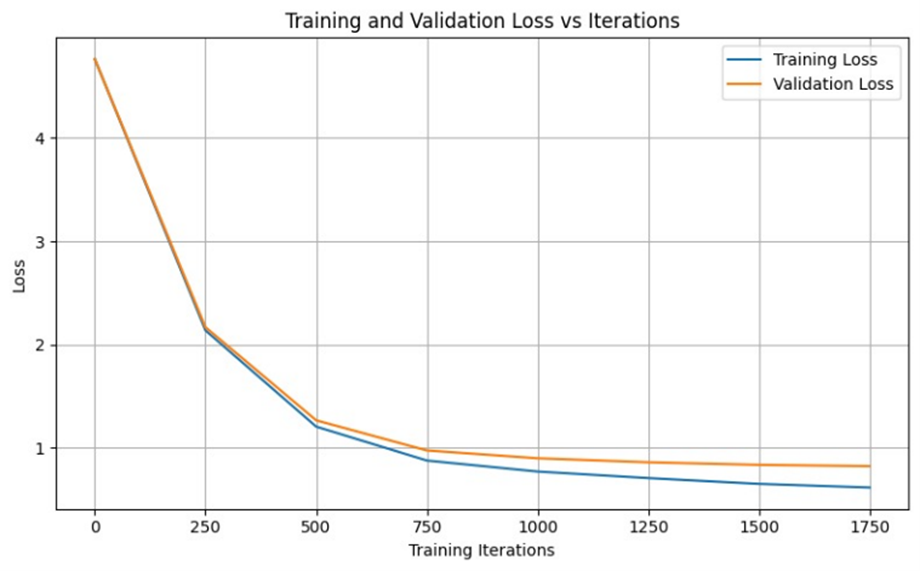

Plots with designated changes:

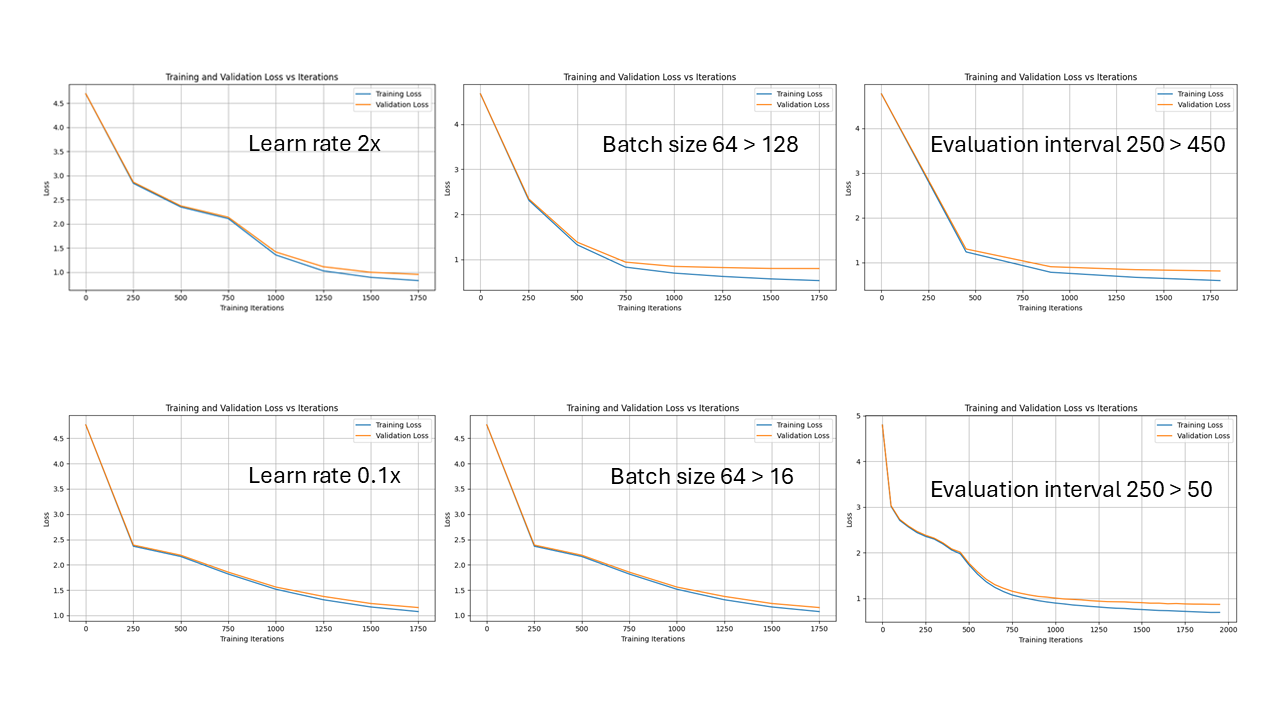